# Step Counter - CNN Data Preparation

This notebook prepares raw windowed accelerometer data for 1D CNN training.

## Approach
1. Window the continuous signal into fixed-size segments (CNN requires fixed-size inputs)
2. Create step count labels for regression
3. Split by participant to train/val/test
4. Save as numpy arrays in /data/processed/

## CNN Input Format
- Shape: (n_windows, window_size, n_channels)
- Example: (136000, 200, 3) for 200 samples × 3 axes (X, Y, Z)
- Optional: Add 4th channel for SMV

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [2]:
# Load data paths

data_path = Path('../data/OxWalk_Dec2022/Hip_100Hz')
metadata_path = Path('../data/OxWalk_Dec2022/metadata.csv')

# Load metadata
metadata = pd.read_csv(metadata_path)
print(f'Total participants: {len(metadata)}')
print(metadata.head())

Total participants: 39
  participant sex    age
0         P01   M  19-30
1         P02   F  45-81
2         P03   M  31-44
3         P04   F  31-44
4         P05   F  45-81


### Windowing Configuration For CNN

CNNs require fixed-size inputs so we cut the original continuous signal into uniform segments. Overlapping windows ensures that no step events are missed at segment boundaries. Three channels are used by default (X, Y, and Z) and an additional channel can be added to utilize the SMV signal.

SMV (Signal Magnitude Vector): The Euclidean norm of the three acceleration axes: √(x² + y² + z²). Represents overall movement intensity, independent of device orientation.

In [3]:
# Configuration

SAMPLING_RATE = 100  # Hz
WINDOW_SIZE_SEC = 2.0  # seconds
WINDOW_SIZE = int(WINDOW_SIZE_SEC * SAMPLING_RATE)  # samples

# Overlap configuration
TRAIN_VAL_OVERLAP = 0.5  # 50% overlap for training and validation
TEST_OVERLAP = 0.0  # 0% overlap for test (non-overlapping windows)

TRAIN_VAL_STEP = int(WINDOW_SIZE * (1 - TRAIN_VAL_OVERLAP))
TEST_STEP = int(WINDOW_SIZE * (1 - TEST_OVERLAP))

# Channel configuration
USE_SMV_CHANNEL = True  # Add SMV as 4th channel

print(f'Window size: {WINDOW_SIZE} samples ({WINDOW_SIZE_SEC} seconds)')
print(f'Train/Val step size: {TRAIN_VAL_STEP} samples ({TRAIN_VAL_STEP/SAMPLING_RATE} seconds, {TRAIN_VAL_OVERLAP*100}% overlap)')
print(f'Test step size: {TEST_STEP} samples ({TEST_STEP/SAMPLING_RATE} seconds, {TEST_OVERLAP*100}% overlap)')
print(f'Add SMV channel: {USE_SMV_CHANNEL}')

Window size: 200 samples (2.0 seconds)
Train/Val step size: 100 samples (1.0 seconds, 50.0% overlap)
Test step size: 200 samples (2.0 seconds, 0.0% overlap)
Add SMV channel: True


### Data Preparation For CNN Training

This section defines the core windowing function that extracts fixed-size segments from continuous accelerometer data and creates labels for CNN training.

Function for processing a single participant's data
- Processes raw accelerometer data into CNN-ready format for a single participant
- Converts continuous time-series into fixed-size windows (200 samples × 3-4 channels)
- Creates step count labels for regression:
    - count: number of steps in the window (0-7)

Print statistics for a test participant and plot a sample window of X, Y, Z, and SMV with steps highlighted.

In [4]:
# Window extraction function

def process_participant_cnn(participant_id, window_size=WINDOW_SIZE, step_size=TRAIN_VAL_STEP,
                            use_smv=USE_SMV_CHANNEL):
    """
    Process a single participant's data and extract raw windowed data for CNN.
    
    Args:
        participant_id: Participant ID (e.g., 'P01')
        window_size: Size of window in samples
        step_size: Step size for sliding window (controls overlap)
        use_smv: Whether to add SMV as 4th channel
    
    Returns:
        windows: numpy array of shape (n_windows, window_size, n_channels)
        labels_dict: dictionary with different label types
        metadata_list: list of metadata dicts for each window
    """
    
    # Load data
    file_path = data_path / f'{participant_id}_hip100.csv'
    df = pd.read_csv(file_path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Calculate derived channels if needed
    if use_smv:
        df['smv'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)
    
    windows_list = []
    labels_count = []
    metadata_list = []
    
    # Sliding window
    for start_idx in range(0, len(df) - window_size + 1, step_size):
        end_idx = start_idx + window_size
        window = df.iloc[start_idx:end_idx]
        
        # Extract raw accelerometer data
        channels = []
        channels.append(window['x'].values)
        channels.append(window['y'].values)
        channels.append(window['z'].values)
        
        if use_smv:
            channels.append(window['smv'].values)
        
        # Stack channels: (window_size, n_channels)
        window_data = np.stack(channels, axis=-1)
        windows_list.append(window_data)
        
        # Create labels
        annotations = window['annotation'].values
        step_count = annotations.sum()

        labels_count.append(step_count)  # Count: how many steps?
        
        # Store metadata
        metadata_list.append({
            'participant': participant_id,
            'window_start': start_idx,
            'window_end': end_idx,
            'timestamp_start': window['timestamp'].iloc[0],
            'timestamp_end': window['timestamp'].iloc[-1]
        })
    
    # Convert to numpy arrays
    windows = np.array(windows_list)  # (n_windows, window_size, n_channels)
    
    labels_dict = {
        'count': np.array(labels_count)  # (n_windows,)
    }
    
    return windows, labels_dict, metadata_list


print('Window extraction function defined')

Window extraction function defined


In [5]:
# Test statistics from a single participant

print('Processing P01...')
test_windows, test_labels, test_metadata = process_participant_cnn('P01')

print(f'\nWindows shape: {test_windows.shape}')
print(f'  - Number of windows: {test_windows.shape[0]}')
print(f'  - Window size (timesteps): {test_windows.shape[1]}')
print(f'  - Number of channels: {test_windows.shape[2]}')

print(f'\nLabels:')
print(f'  - Count shape: {test_labels["count"].shape}')

print(f'\nLabel distributions:')
print(f'  - Count statistics:')
print(f'    Mean: {test_labels["count"].mean():.2f}')
print(f'    Std: {test_labels["count"].std():.2f}')
print(f'    Max: {test_labels["count"].max()}')
print(f'    Total steps: {test_labels["count"].sum()}')

print(f'\nFirst window data sample:')
print(f'Shape: {test_windows[0].shape}')
print(f'First 5 timesteps:')
print(test_windows[0][:5])

Processing P01...

Windows shape: (3598, 200, 4)
  - Number of windows: 3598
  - Window size (timesteps): 200
  - Number of channels: 4

Labels:
  - Count shape: (3598,)

Label distributions:
  - Count statistics:
    Mean: 0.48
    Std: 1.23
    Max: 5
    Total steps: 1734

First window data sample:
Shape: (200, 4)
First 5 timesteps:
[[ 0.999302    0.209971   -0.056493    1.02268459]
 [ 0.999302    0.219931   -0.056493    1.02477587]
 [ 1.001408    0.228453   -0.056493    1.02868859]
 [ 0.991524    0.228548   -0.056493    1.01909052]
 [ 0.981246    0.219577   -0.056493    1.00709941]]


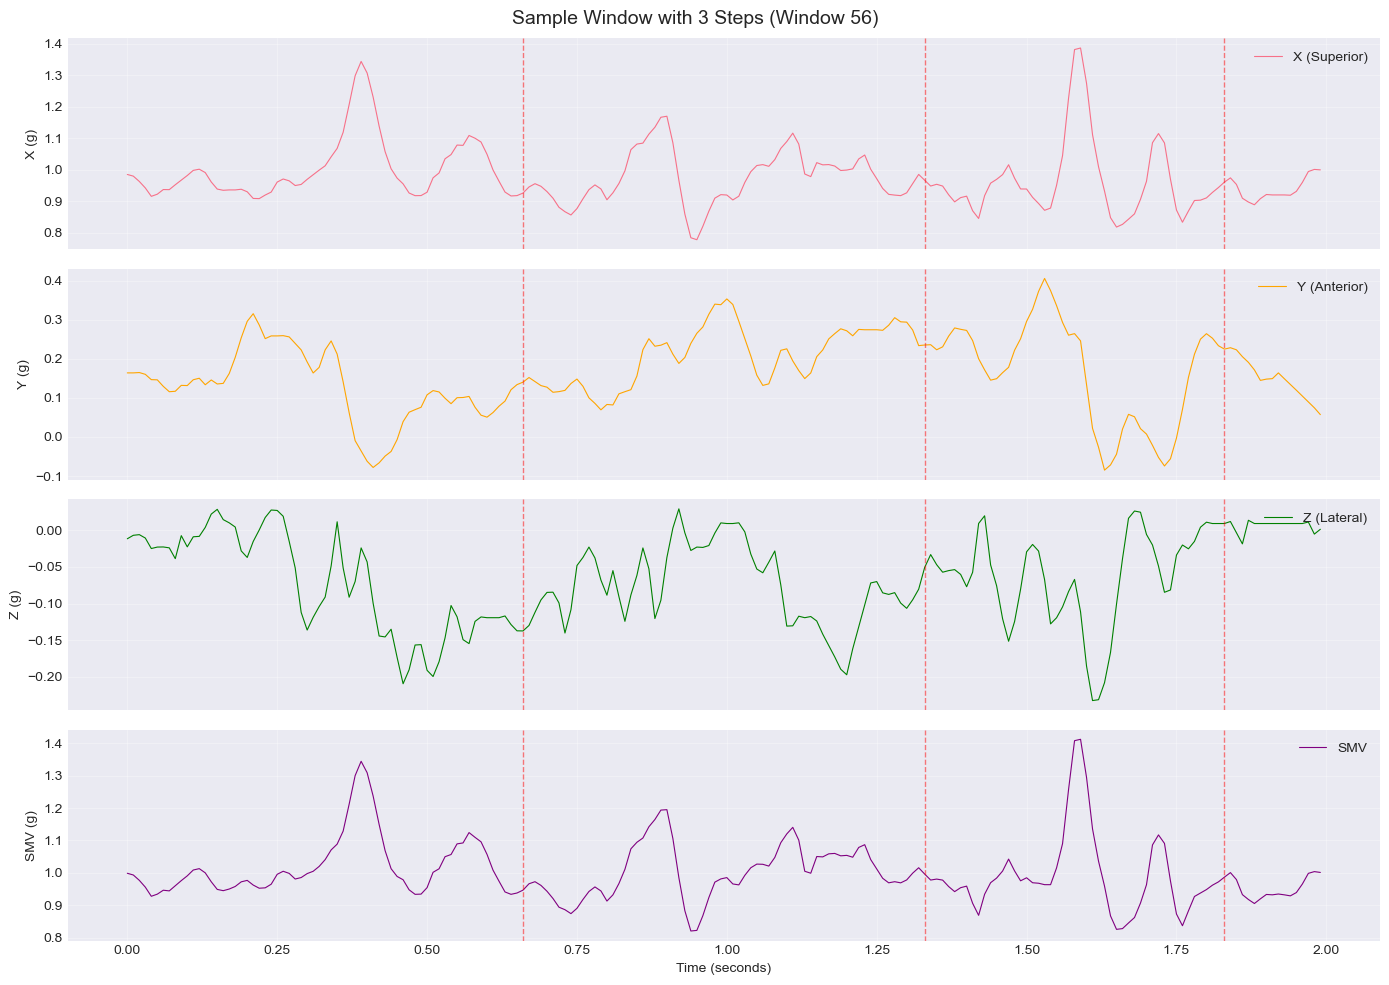

Window 56: 3 steps


In [6]:
# Visualize a sample window with steps

# Find a window with steps
step_window_idx = np.where(test_labels['count'] > 0)[0][10]  # 10th window with steps

# Load original data to get annotations for visualization
file_path = data_path / 'P01_hip100.csv'
df = pd.read_csv(file_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])
if USE_SMV_CHANNEL:
    df['smv'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)

# Extract the same window for annotations
start_idx = test_metadata[step_window_idx]['window_start']
end_idx = test_metadata[step_window_idx]['window_end']
sample_window = test_windows[step_window_idx]
sample_annotations = df.iloc[start_idx:end_idx]['annotation'].values

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

time = np.arange(WINDOW_SIZE) / SAMPLING_RATE

# Plot each channel
axes[0].plot(time, sample_window[:, 0], label='X (Superior)', linewidth=0.8)
axes[0].set_ylabel('X (g)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time, sample_window[:, 1], label='Y (Anterior)', color='orange', linewidth=0.8)
axes[1].set_ylabel('Y (g)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

axes[2].plot(time, sample_window[:, 2], label='Z (Lateral)', color='green', linewidth=0.8)
axes[2].set_ylabel('Z (g)')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

if USE_SMV_CHANNEL:
    axes[3].plot(time, sample_window[:, 3], label='SMV', color='purple', linewidth=0.8)
    axes[3].set_ylabel('SMV (g)')
    axes[3].legend(loc='upper right')
    axes[3].grid(True, alpha=0.3)

# Mark step annotations
step_times = time[sample_annotations == 1]
for ax in axes:
    for step_time in step_times:
        ax.axvline(step_time, color='red', linestyle='--', alpha=0.5, linewidth=1)

axes[3].set_xlabel('Time (seconds)')
plt.suptitle(f'Sample Window with {sample_annotations.sum()} Steps (Window {step_window_idx})', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Window {step_window_idx}: {sample_annotations.sum()} steps')

### Prepare Data For All Participants

This section processes all 39 participants using the windowing function and aggregates the results into a single dataset.

For each participant:
- Extract windows using the defined configuration
- Generate step count labels
- Append demographic information (age, sex) to window metadata
- Track participant IDs to enable proper train/test splitting

Visualize dataset-level statistics:
- Step count distribution: Histogram showing frequency of different step counts per window
- Accelerometer distributions: Value distributions for X, Y, Z axes and SMV channels across all windows

In [7]:
# Process all participants for train and validation (with overlap)

train_val_windows = []
train_val_labels_count = []
train_val_metadata = []
train_val_participants = []

for idx, row in metadata.iterrows():
    pid = row['participant']
    try:
        print(f'Processing {pid} (train/val)...', end=' ')
        windows, labels, metadata_list = process_participant_cnn(pid, step_size=TRAIN_VAL_STEP)
        
        train_val_windows.append(windows)
        train_val_labels_count.append(labels['count'])
        
        # Add demographic info to metadata
        for meta in metadata_list:
            meta['sex'] = row['sex']
            meta['age'] = row['age']
            meta['split_type'] = 'train_val'

        train_val_metadata.extend(metadata_list)
        
        # Track participant for each window
        train_val_participants.extend([pid] * len(windows))
        
        print(f'{len(windows)} windows')

    except Exception as e:
        print(f'Error: {e}')

# Combine all participants for train/val
X_train_val = np.concatenate(train_val_windows, axis=0)
y_train_val_count = np.concatenate(train_val_labels_count, axis=0)
participants_train_val = np.array(train_val_participants)

print(f'\n=== Train/Val Dataset (50% overlap) ===')
print(f'Total windows: {len(X_train_val)}')
print(f'X shape: {X_train_val.shape}')

# Process test participants separately (no overlap)
test_windows = []
test_labels_count = []
test_metadata = []
test_participants = []

for idx, row in metadata.iterrows():
    pid = row['participant']
    try:
        print(f'Processing {pid} (test)...', end=' ')
        windows, labels, metadata_list = process_participant_cnn(pid, step_size=TEST_STEP)
        
        test_windows.append(windows)
        test_labels_count.append(labels['count'])
        
        # Add demographic info to metadata
        for meta in metadata_list:
            meta['sex'] = row['sex']
            meta['age'] = row['age']
            meta['split_type'] = 'test'

        test_metadata.extend(metadata_list)
        
        # Track participant for each window
        test_participants.extend([pid] * len(windows))
        
        print(f'{len(windows)} windows')

    except Exception as e:
        print(f'Error: {e}')

# Combine all test participants
X_test_all = np.concatenate(test_windows, axis=0)
y_test_all_count = np.concatenate(test_labels_count, axis=0)
participants_test_all = np.array(test_participants)

print(f'\n=== Test Dataset (0% overlap) ===')
print(f'Total windows: {len(X_test_all)}')
print(f'X shape: {X_test_all.shape}')

Processing P01 (train/val)... 3598 windows
Processing P02 (train/val)... 3599 windows
Processing P03 (train/val)... 3599 windows
Processing P04 (train/val)... 3598 windows
Processing P05 (train/val)... 3599 windows
Processing P06 (train/val)... 3598 windows
Processing P07 (train/val)... 3599 windows
Processing P08 (train/val)... 3598 windows
Processing P09 (train/val)... 3599 windows
Processing P10 (train/val)... 3599 windows
Processing P11 (train/val)... 3598 windows
Processing P12 (train/val)... 3367 windows
Processing P13 (train/val)... 2338 windows
Processing P14 (train/val)... 3598 windows
Processing P15 (train/val)... 3598 windows
Processing P16 (train/val)... 3599 windows
Processing P17 (train/val)... 3598 windows
Processing P18 (train/val)... 3598 windows
Processing P19 (train/val)... 3598 windows
Processing P20 (train/val)... 3598 windows
Processing P21 (train/val)... 3598 windows
Processing P22 (train/val)... 3598 windows
Processing P23 (train/val)... 3599 windows
Processing 

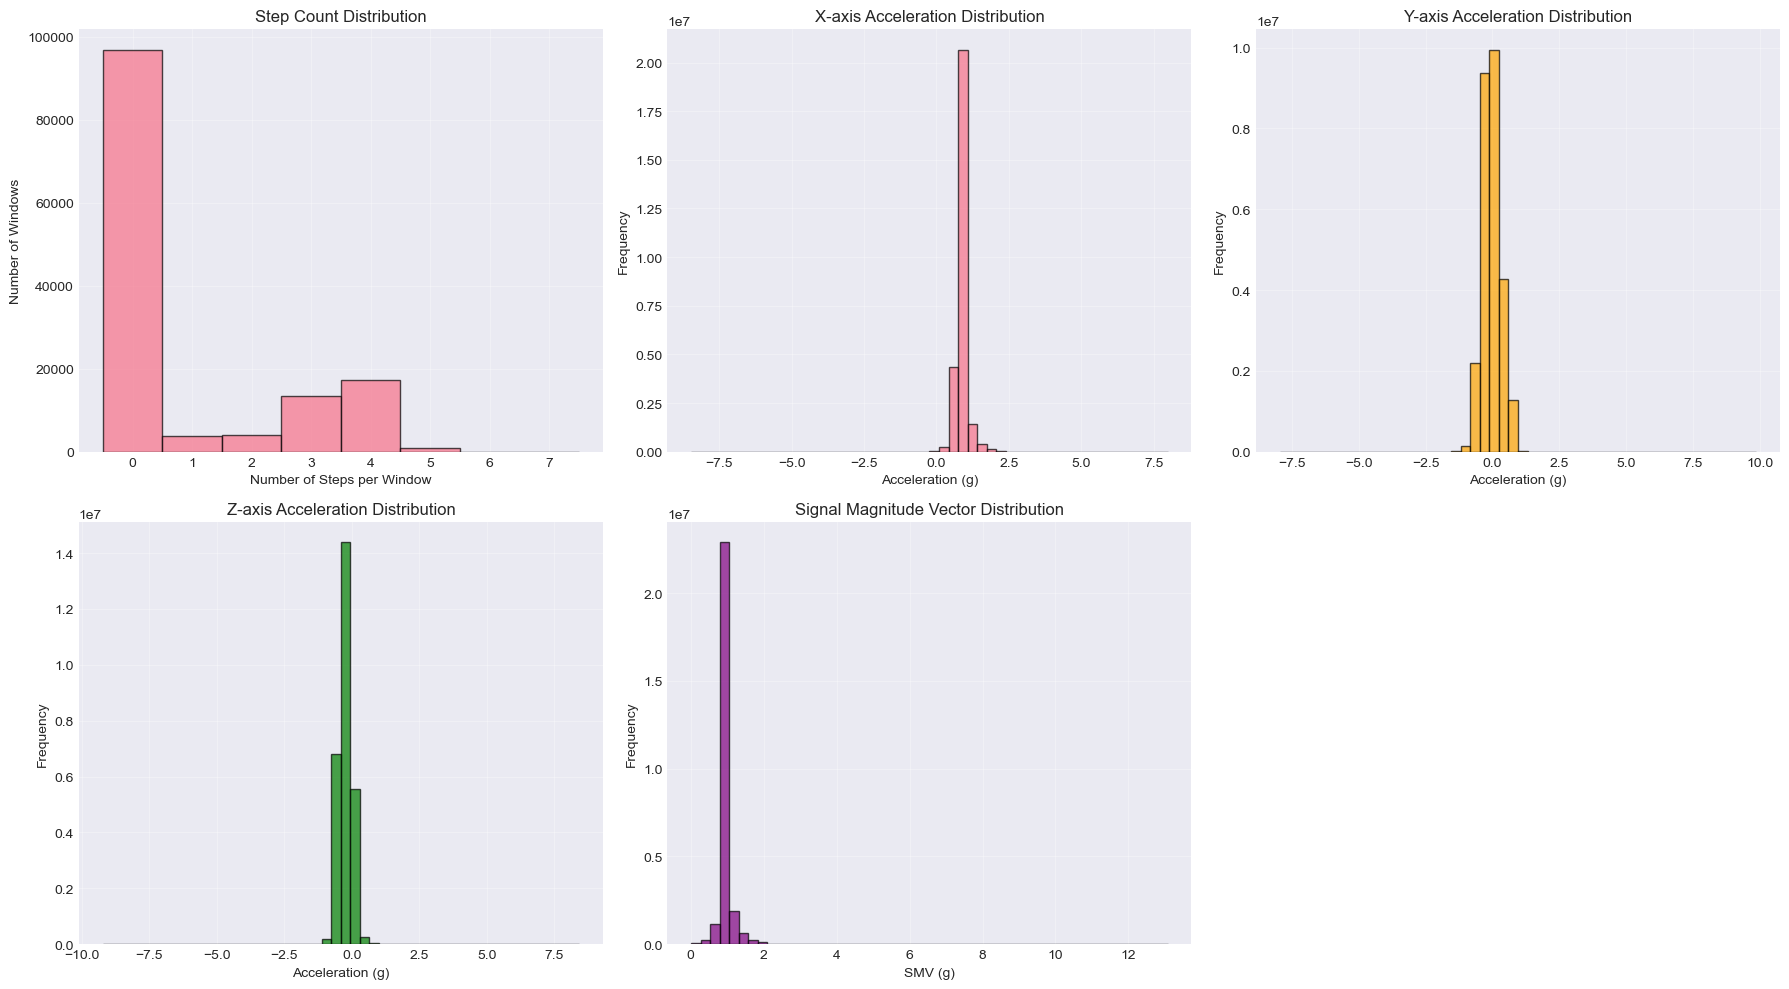

In [8]:
# Visualize data statistics

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Step count distribution
bins = np.arange(int(y_train_val_count.max()) + 2)
axes[0, 0].hist(y_train_val_count, bins=bins, edgecolor='black', alpha=0.7, align='left')
axes[0, 0].set_xlabel('Number of Steps per Window')
axes[0, 0].set_ylabel('Number of Windows')
axes[0, 0].set_title('Step Count Distribution')
axes[0, 0].grid(True, alpha=0.3)

# Accelerometer value distribution (all windows, X axis)
axes[0, 1].hist(X_train_val[:, :, 0].flatten(), bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Acceleration (g)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('X-axis Acceleration Distribution')
axes[0, 1].grid(True, alpha=0.3)

# Y-axis acceleration distribution
axes[0, 2].hist(X_train_val[:, :, 1].flatten(), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 2].set_xlabel('Acceleration (g)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Y-axis Acceleration Distribution')
axes[0, 2].grid(True, alpha=0.3)

# Z-axis acceleration distribution
axes[1, 0].hist(X_train_val[:, :, 2].flatten(), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('Acceleration (g)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Z-axis Acceleration Distribution')
axes[1, 0].grid(True, alpha=0.3)

# SMV distribution if available
if USE_SMV_CHANNEL:
    axes[1, 1].hist(X_train_val[:, :, 3].flatten(), bins=50, edgecolor='black', alpha=0.7, color='purple')
    axes[1, 1].set_xlabel('SMV (g)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Signal Magnitude Vector Distribution')
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].axis('off')

# Hide unused subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


### Train/Validation/Test Split by Participant

This section splits the dataset into training, validation, and testing sets based on participants to prevent data leakage. Splitting the separated windows randomly would likely overfit the model for couple of reasons: the windows may have overlap, consecutive windows may be highly correlated, and overall the test subjects have different walking patterns.

The split is performed in two stages:
1. First split: 80% train+val, 20% test
2. Second split: 75% train, 25% val (of train+val) = 60% train, 20% val, 20% test overall

The validation data will be used to monitor the model's performance during training. The test set is used to evaluate the final model's performance.

All windows from a given participant stay together in their assigned split.

Print statistics showing:
- Number of participants in each split
- Shape of feature and label arrays
- Total step counts in train, validation, and test sets


In [9]:
# Train/val/test split by participant

unique_participants = metadata['participant'].unique()

# First split: 80% train+val, 20% test
train_val_pids, test_pids = train_test_split(unique_participants, test_size=0.2, random_state=42)

# Second split: 75% train, 25% val (of the train+val set = 60% train, 20% val overall)
train_pids, val_pids = train_test_split(train_val_pids, test_size=0.25, random_state=42)

print(f'Total participants: {len(unique_participants)}')
print(f'Train participants: {len(train_pids)} ({len(train_pids) / len(unique_participants) * 100:.1f}%)')
print(f'Val participants: {len(val_pids)} ({len(val_pids) / len(unique_participants) * 100:.1f}%)')
print(f'Test participants: {len(test_pids)} ({len(test_pids) / len(unique_participants) * 100:.1f}%)')
print(f'\nVal participants: {sorted(val_pids)}')
print(f'Test participants: {sorted(test_pids)}')

# Split train/val data (from overlapping dataset)
train_mask_tv = np.isin(participants_train_val, train_pids)
val_mask_tv = np.isin(participants_train_val, val_pids)

X_train = X_train_val[train_mask_tv]
X_val = X_train_val[val_mask_tv]

y_train_count = y_train_val_count[train_mask_tv]
y_val_count = y_train_val_count[val_mask_tv]

# Split test data (from non-overlapping dataset)
test_mask = np.isin(participants_test_all, test_pids)

X_test = X_test_all[test_mask]
y_test_count = y_test_all_count[test_mask]

print(f'\n=== Train Set (50% overlap) ===')
print(f'X_train shape: {X_train.shape}')
print(f'Total steps: {y_train_count.sum()}')
print(f'Mean steps per window: {y_train_count.mean():.2f}')

print(f'\n=== Validation Set (50% overlap) ===')
print(f'X_val shape: {X_val.shape}')
print(f'Total steps: {y_val_count.sum()}')
print(f'Mean steps per window: {y_val_count.mean():.2f}')

print(f'\n=== Test Set (0% overlap - non-overlapping windows) ===')
print(f'X_test shape: {X_test.shape}')
print(f'Total steps: {y_test_count.sum()}')
print(f'Mean steps per window: {y_test_count.mean():.2f}')

Total participants: 39
Train participants: 23 (59.0%)
Val participants: 8 (20.5%)
Test participants: 8 (20.5%)

Val participants: ['P01', 'P08', 'P11', 'P22', 'P23', 'P29', 'P30', 'P33']
Test participants: ['P05', 'P07', 'P14', 'P27', 'P28', 'P31', 'P34', 'P37']

=== Train Set (50% overlap) ===
X_train shape: (81272, 200, 4)
Total steps: 74199
Mean steps per window: 0.91

=== Validation Set (50% overlap) ===
X_val shape: (28787, 200, 4)
Total steps: 36526
Mean steps per window: 1.27

=== Test Set (0% overlap - non-overlapping windows) ===
X_test shape: (13135, 200, 4)
Total steps: 7532
Mean steps per window: 0.57


## Normalization/Standardization

The standardization helps learning and results in better generalization. The inputs are scaled to have zero mean and unit variance. This ensures that no single channel dominates the learning process, and that gradients remain stable during backpropagation (no vanishing/exploding gradients). The standardization is performed using the training data only to prevent data leakage.



In [10]:
# Data standardization

# Calculate statistics from training data only
train_mean = X_train.mean(axis=(0, 1))  # Mean per channel
train_std = X_train.std(axis=(0, 1))  # Std per channel

print('Training data statistics (per channel):')
channel_names = ['X', 'Y', 'Z']
if USE_SMV_CHANNEL:
    channel_names.append('SMV')

for i, name in enumerate(channel_names):
    print(f'  {name}: mean={train_mean[i]:.4f}, std={train_std[i]:.4f}')

# Normalize (standardize) the data
X_train_norm = (X_train - train_mean) / train_std
X_val_norm = (X_val - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

print(f'\nNormalized train data: mean={X_train_norm.mean():.4f}, std={X_train_norm.std():.4f}')
print(f'Normalized val data: mean={X_val_norm.mean():.4f}, std={X_val_norm.std():.4f}')
print(f'Normalized test data: mean={X_test_norm.mean():.4f}, std={X_test_norm.std():.4f}')


Training data statistics (per channel):
  X: mean=0.8969, std=0.2013
  Y: mean=0.0438, std=0.3019
  Z: mean=-0.2231, std=0.2408
  SMV: mean=1.0085, std=0.1692

Normalized train data: mean=0.0000, std=1.0000
Normalized val data: mean=-0.1848, std=1.0431
Normalized test data: mean=-0.3069, std=0.9632


### Save Processed Data

This section saves all processed data to disk for use in CNN model training.

Arrays saved:
- `cnn_train_data.npz`: Training features (X_train_norm) and step count labels
- `cnn_val_data.npz`: Validation features (X_val_norm) and step count labels
- `cnn_test_data.npz`: Test features (X_test_norm) and step count labels
- `cnn_normalization.npz`: Mean and std per channel for denormalization

Metadata saved:
- `cnn_train_participants.csv`: List of participant IDs in training set
- `cnn_val_participants.csv`: List of participant IDs in validation set
- `cnn_test_participants.csv`: List of participant IDs in test set
- `cnn_window_metadata.csv`: Window-level metadata (timestamps, demographics)


The `.npz` format is NumPy's compressed archive format that stores multiple arrays in a single file. It uses ZIP compression internally, providing efficient storage while maintaining fast loading speeds. This format is ideal for machine learning workflows as it preserves array dtypes and shapes, and allows selective loading of specific arrays without reading the entire file into memory.

In [11]:
# Save processed data

output_dir = Path('../data/processed')
output_dir.mkdir(parents=True, exist_ok=True)

# Save as compressed numpy format (.npz)
print('Saving training data...')
np.savez_compressed(
    output_dir / 'cnn_train_data.npz',
    X=X_train_norm,
    y_count=y_train_count,
    participants=participants_train_val[train_mask_tv]
)
print(f'Saved: {output_dir / "cnn_train_data.npz"}')

print('Saving validation data...')
np.savez_compressed(
    output_dir / 'cnn_val_data.npz',
    X=X_val_norm,
    y_count=y_val_count,
    participants=participants_train_val[val_mask_tv]
)
print(f'Saved: {output_dir / "cnn_val_data.npz"}')

print('Saving test data...')
np.savez_compressed(
    output_dir / 'cnn_test_data.npz',
    X=X_test_norm,
    y_count=y_test_count,
    participants=participants_test_all[test_mask]
)
print(f'Saved: {output_dir / "cnn_test_data.npz"}')

# Save normalization parameters
print('Saving normalization parameters...')
np.savez(
    output_dir / 'cnn_normalization.npz',
    mean=train_mean,
    std=train_std,
    channel_names=channel_names
)
print(f'Saved: {output_dir / "cnn_normalization.npz"}')

# Save participant splits
pd.DataFrame({'participant': train_pids, 'split': 'train'}).to_csv(
    output_dir / 'cnn_train_participants.csv', index=False
)
pd.DataFrame({'participant': val_pids, 'split': 'val'}).to_csv(
    output_dir / 'cnn_val_participants.csv', index=False
)
pd.DataFrame({'participant': test_pids, 'split': 'test'}).to_csv(
    output_dir / 'cnn_test_participants.csv', index=False
)
print(f'Saved participant splits')

# Save metadata
all_metadata_combined = train_val_metadata + test_metadata
pd.DataFrame(all_metadata_combined).to_csv(output_dir / 'cnn_window_metadata.csv', index=False)
print(f'Saved window metadata')

print('\n=== Data Preparation Complete! ===')
print(f'\nFiles saved to: {output_dir.absolute()}')
print(f'\nDataset configuration:')
print(f'  - Train/Val: 50% overlap (more training data)')
print(f'  - Test: 0% overlap (fair evaluation, no double-counting)')
print(f'\nTo load the data in your CNN training script:')
print(f'```python')
print(f'train_data = np.load("../data/processed/cnn_train_data.npz")')
print(f'X_train = train_data["X"]')
print(f'y_train = train_data["y_count"]')
print(f'```')

Saving training data...
Saved: ..\data\processed\cnn_train_data.npz
Saving validation data...
Saved: ..\data\processed\cnn_val_data.npz
Saving test data...
Saved: ..\data\processed\cnn_test_data.npz
Saving normalization parameters...
Saved: ..\data\processed\cnn_normalization.npz
Saved participant splits
Saved window metadata

=== Data Preparation Complete! ===

Files saved to: C:\Users\PekkoKauppila\Private\Machine-Learning-Projects\Step_counter_project\notebooks\..\data\processed

Dataset configuration:
  - Train/Val: 50% overlap (more training data)
  - Test: 0% overlap (fair evaluation, no double-counting)

To load the data in your CNN training script:
```python
train_data = np.load("../data/processed/cnn_train_data.npz")
X_train = train_data["X"]
y_train = train_data["y_count"]
```
